## Set Config

In [1]:
# ライブラリのインポート
import os
import numpy as np
import polars as pl
import pyarrow
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import h2o
from h2o.automl import H2OAutoML
from h2o.frame import H2OFrame
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerPatch
import matplotlib.patches as patches

from sklearn.metrics import precision_recall_curve, auc

In [2]:
# フォルダ設定
data_dir = '../data/'
output_dir = '../output/'
result_dir = '../output/results'

# date, version
# dateはデータを出力した日付で、特徴量tableにファイル名に含まれる
# 同じ特徴量tableに対して複数回のモデル構築を行う場合は、versionを変更する
date = '20260202_emergency'
within = '72h'

# type. version
model_type_1 = 'full'
ver_no_1 = 1

### model to compare 2
# type. version
model_type_2 = 'minimum'
ver_no_2 = 1

### model to compare 3
# type. version
model_type_3 = 'compact'
ver_no_3 = 1

In [3]:
# データのファイル名
df_development_test_all_file_name = f'{date}_df_development_{within}_test_sampled_baseline.csv'

In [4]:
# 保存するフォルダやファイル名を指定
roc_figure_development_name = date + '_' + within + '_model_ver' + '_3_ROC_curve.png'
prc_figure_development_name = date + '_' + within + '_model_ver' + '_3_PRC_curve.png'

In [5]:
figure_colors = [
    '#6CC5B0', # red
    '#FF8AB7', # blue
    '#4269D0', # orange
    '#374e55' # gray
]

In [6]:
# H2Oの初期化
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,21 hours 28 mins
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.5
H2O_cluster_version_age:,"1 year, 5 months and 25 days"
H2O_cluster_name:,H2O_from_python_unknownUser_zl3h0i
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,20.19 Gb
H2O_cluster_total_cores:,28
H2O_cluster_allowed_cores:,28
H2O_cluster_status:,"locked, healthy"


## Load Model

In [7]:
# 作成したモデルの読み込み
model_1_without_lag_path_file = f'./model_path/{date}_{model_type_1}_{within}_model_ver{ver_no_1}_model_path_without_lag.txt'
model_2_path_file = f'./model_path/{date}_{model_type_2}_{within}_model_ver{ver_no_2}_model_path.txt'
# '/workspaces/research-nms-delirium-2025-4/output/results/20260202_emergency_minimum_24h_model_ver1_h2omodel_best/XGBoost_grid_1_AutoML_2_20260201_171741_model_18'

model_3_path_file = f'./model_path/{date}_{model_type_3}_{within}_model_ver{ver_no_3}_model_path.txt'

with open(model_1_without_lag_path_file, "r", encoding="utf-8") as f:
    path = f.readline().strip()  # 1行目を取得し、空白や改行を削除
    model_1_without_lag = h2o.load_model(path)

# model_2 = h2o.load_model(model_2_path_file)

with open(model_2_path_file, "r", encoding="utf-8") as f:
    path = f.readline().strip()  # 1行目を取得し、空白や改行を削除
    model_2 = h2o.load_model(path)

with open(model_3_path_file, "r", encoding="utf-8") as f:
    path = f.readline().strip()  # 1行目を取得し、空白や改行を削除
    model_3 = h2o.load_model(path)

## Run Prediction

In [8]:
### development test data ###
# データの読み込み
h2o_dev_all  = h2o.import_file(os.path.join(data_dir, df_development_test_all_file_name))
h2o_dev_with_lag = h2o_dev_all[h2o_dev_all["time_window_index"] >= 12, :]
h2o_dev_without_lag = h2o_dev_all[h2o_dev_all["time_window_index"] < 12, :]

df_dev_pandas = h2o_dev_all.as_data_frame(use_multi_thread=True)
df_dev_polars = pl.from_pandas(df_dev_pandas)
df_dev_polars = df_dev_polars.sort(["icu_stay_id", "time_window_index"])

Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


In [9]:
# 2) 3つとも「同じ h2o_dev_without_lag」で予測
pred_dev1_without = model_1_without_lag.predict(h2o_dev_without_lag).as_data_frame(use_multi_thread=True)
pred_dev2 = model_2.predict(h2o_dev_without_lag).as_data_frame(use_multi_thread=True)
pred_dev3 = model_3.predict(h2o_dev_without_lag).as_data_frame(use_multi_thread=True)


xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


In [10]:
# 3) polarsに揃えて結合（行数が一致する）
df_dev_polars = pl.from_pandas(h2o_dev_without_lag.as_data_frame(use_multi_thread=True))
p_dev1 = pl.from_pandas(pred_dev1_without).select(pl.col("p1").alias("model_1_prediction"))
p_dev2 = pl.from_pandas(pred_dev2).select(pl.col("p1").alias("model_2_prediction"))
p_dev3 = pl.from_pandas(pred_dev3).select(pl.col("p1").alias("model_3_prediction"))

df_development_test_all = (
    df_dev_polars
    .with_columns([
        p_dev1["model_1_prediction"],
        p_dev2["model_2_prediction"],
        p_dev3["model_3_prediction"],
    ])
)

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


In [11]:
# メモリ節約
del df_dev_polars
del h2o_dev_without_lag, h2o_dev_all
del pred_dev1_without, pred_dev2, pred_dev3

## AUROC曲線の描画

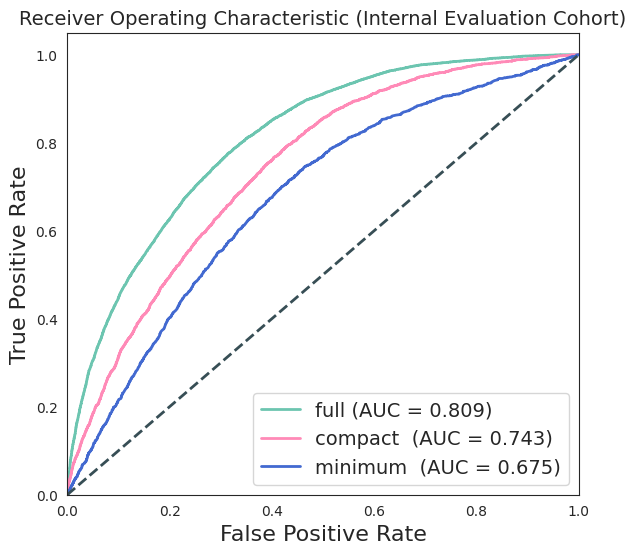

In [12]:
# Compute ROC curve and ROC area
fpr1, tpr1, _ = roc_curve(df_development_test_all['y'], df_development_test_all['model_1_prediction'])
roc_auc1 = auc(fpr1, tpr1)

fpr2, tpr2, _ = roc_curve(df_development_test_all['y'], df_development_test_all['model_2_prediction'])
roc_auc2 = auc(fpr2, tpr2)

fpr3, tpr3, _ = roc_curve(df_development_test_all['y'], df_development_test_all['model_3_prediction'])
roc_auc3 = auc(fpr3, tpr3)

# Plotting the ROC curve
plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(6.6, 6))
sns.set_style("white")
plt.plot(fpr1, tpr1, color=figure_colors[0], lw=2, label=f'{model_type_1} (AUC = {roc_auc1:.3f})')
plt.plot(fpr3, tpr3, color=figure_colors[1], lw=2, label=f'{model_type_3}  (AUC = {roc_auc3:.3f})')
plt.plot(fpr2, tpr2, color=figure_colors[2], lw=2, label=f'{model_type_2}  (AUC = {roc_auc2:.3f})')
plt.plot([0, 1], [0, 1], color=figure_colors[3], lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('Receiver Operating Characteristic (Internal Evaluation Cohort)', fontsize=14)
plt.legend(loc="lower right", fontsize=14)

plt.savefig(os.path.join(output_dir, 'figures/' + roc_figure_development_name))
plt.show()

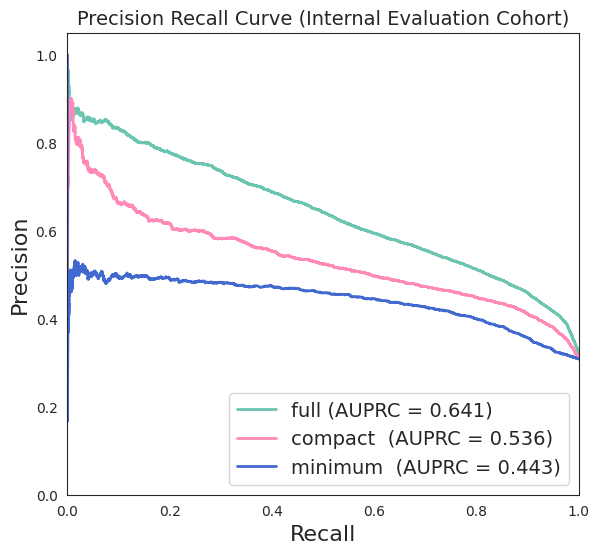

In [13]:
# Compute PR curve and PR area
precision1, recall1, _ = precision_recall_curve(
    df_development_test_all['y'],
    df_development_test_all['model_1_prediction']
)
aucpr1 = auc(recall1, precision1)

precision2, recall2, _ = precision_recall_curve(
    df_development_test_all['y'],
    df_development_test_all['model_2_prediction']
)
aucpr2 = auc(recall2, precision2)

precision3, recall3, _ = precision_recall_curve(
    df_development_test_all['y'],
    df_development_test_all['model_3_prediction']
)
aucpr3 = auc(recall3, precision3)

# Plotting the PR curve
plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(6.6, 6))
sns.set_style("white")

plt.plot(recall1, precision1, color=figure_colors[0], lw=2,
         label=f'{model_type_1} (AUPRC = {aucpr1:.3f})')

plt.plot(recall3, precision3, color=figure_colors[1], lw=2,
         label=f'{model_type_3}  (AUPRC = {aucpr3:.3f})')

plt.plot(recall2, precision2, color=figure_colors[2], lw=2,
         label=f'{model_type_2}  (AUPRC = {aucpr2:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=16)
plt.ylabel('Precision', fontsize=16)
plt.title('Precision Recall Curve (Internal Evaluation Cohort)', fontsize=14)
plt.legend(loc="lower right", fontsize=14)

plt.savefig(os.path.join(output_dir, 'figures/' + prc_figure_development_name))
plt.show()
